# 08 Dual-Label Entry Analysis

Analyzes the car-entry and pedestrian-entry coordinates produced by the dual-annotation pipeline in `ground_truth.py`. These coordinates were generated by GPT-4o for every Tier 1/2 place — no manual labeling required.

Run all cells top to bottom.

## Setup

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.multipin_pilot import build_multipin_pilot, write_summary
from src.metrics import haversine_meters

PROCESSED = PROJECT_ROOT / "data" / "processed"


## Step 1: Build dual-label dataset

Pulls all rows from the ground truth that have both `car_entry` and `pedestrian_entry` coordinates.

In [2]:
df = build_multipin_pilot()
df.to_csv(PROCESSED / "multipin" / "multipin_pilot.csv", index=False)
write_summary(df)

print(f"Dual-labeled rows: {len(df)}")
df[["tier_label", "place_complexity"]].value_counts().head(10)


Dual-labeled rows: 2463


tier_label           place_complexity
standard_commercial  simple              2081
                     complex              147
multi_tenant         simple               132
standard_commercial  multi_tenant          72
multi_tenant         complex               27
                     multi_tenant           4
Name: count, dtype: int64

## Step 2: Car/pedestrian separation overview

How far apart are the two entry points that GPT-4o identified?

In [3]:
sep = df["car_pedestrian_distance_m"]

print("Car/pedestrian separation (m):")
print(sep.describe().round(2).to_string())
print()
print(f"Separation >= 10m:  {(sep >= 10).mean()*100:.1f}%  ({(sep >= 10).sum()} rows)")
print(f"Separation >= 25m:  {(sep >= 25).mean()*100:.1f}%  ({(sep >= 25).sum()} rows)")
print(f"Separation >= 50m:  {(sep >= 50).mean()*100:.1f}%  ({(sep >= 50).sum()} rows)")


Car/pedestrian separation (m):
count    2463.00
mean       21.54
std        19.71
min         0.00
25%         0.00
50%        20.88
75%        28.51
max       118.52

Separation >= 10m:  70.8%  (1745 rows)
Separation >= 25m:  28.0%  (690 rows)
Separation >= 50m:  9.3%  (229 rows)


## Step 3: Separation by tier

In [4]:
df.groupby("tier_label")["car_pedestrian_distance_m"].describe().round(2)


,count,mean,std,min,25%,50%,75%,max
tier_label,,,,,,,,
multi_tenant,163.0,28.45,14.50,17.69,20.76,22.76,29.86,105.67
standard_commercial,2300.0,21.05,19.94,0.00,0.00,20.59,28.03,118.52


In [5]:
df.groupby("tier_label")["car_pedestrian_distance_m"].agg(
    count="count",
    median="median",
    p90=lambda x: x.quantile(0.90),
    p95=lambda x: x.quantile(0.95),
    pct_over_10m=lambda x: (x >= 10).mean() * 100,
    pct_over_25m=lambda x: (x >= 25).mean() * 100,
).round(2)


,count,median,p90,p95,pct_over_10m,pct_over_25m
tier_label,,,,,,
multi_tenant,163,22.76,35.34,65.29,100.00,42.94
standard_commercial,2300,20.59,45.62,67.03,68.78,26.96


## Step 4: Separation by place_complexity

In [6]:
df.groupby("place_complexity")["car_pedestrian_distance_m"].agg(
    count="count",
    median="median",
    p90=lambda x: x.quantile(0.90),
    p95=lambda x: x.quantile(0.95),
    pct_over_10m=lambda x: (x >= 10).mean() * 100,
    pct_over_25m=lambda x: (x >= 25).mean() * 100,
).round(2)


,count,median,p90,p95,pct_over_10m,pct_over_25m
place_complexity,,,,,,
complex,174,21.83,65.59,70.60,78.74,38.51
multi_tenant,76,22.04,44.27,63.21,72.37,32.89
simple,2213,20.74,42.92,66.72,70.18,27.02


## Step 5: Top categories by median separation

Which place types have the largest gap between car and pedestrian entry?

In [7]:
cat_sep = (
    df.groupby("category_primary")["car_pedestrian_distance_m"]
    .agg(count="count", median="median", p90=lambda x: x.quantile(0.9))
    .query("count >= 10")
    .sort_values("median", ascending=False)
    .round(2)
)
cat_sep.head(20)


,count,median,p90
category_primary,,,
supermarket,21,33.98,71.12
department_store,15,32.86,85.19
shopping_center,11,30.09,66.52
burger_restaurant,17,28.82,43.84
building_supply_store,13,27.74,62.06
arts_and_crafts,12,26.28,66.73
auto_parts_and_supply_store,10,25.81,59.21
mobile_phone_accessories,10,23.32,59.58
fast_food_restaurant,59,23.30,50.14


## Step 6: Distribution plot

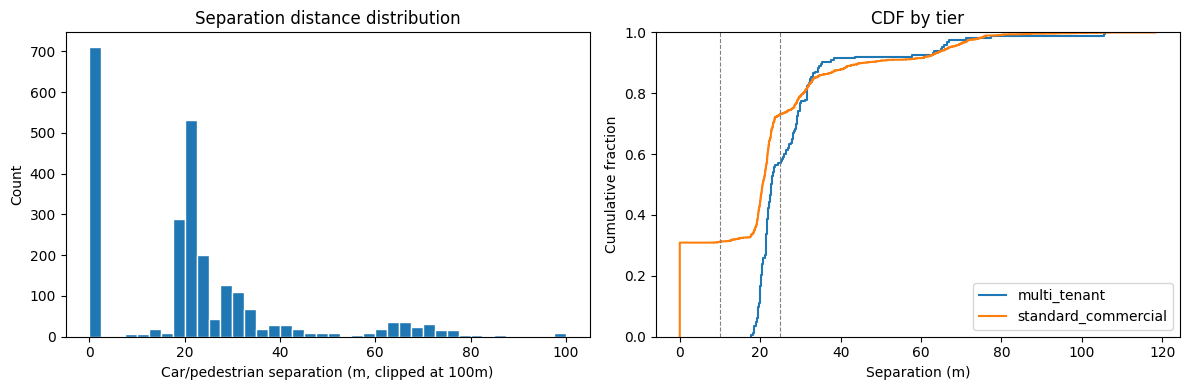

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["car_pedestrian_distance_m"].clip(upper=100), bins=40, edgecolor="white")
axes[0].set_xlabel("Car/pedestrian separation (m, clipped at 100m)")
axes[0].set_ylabel("Count")
axes[0].set_title("Separation distance distribution")

for tier, grp in df.groupby("tier_label"):
    axes[1].ecdf(grp["car_pedestrian_distance_m"], label=tier)
axes[1].set_xlabel("Separation (m)")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("CDF by tier")
axes[1].legend()
axes[1].axvline(10, color="gray", linestyle="--", linewidth=0.8)
axes[1].axvline(25, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig(PROCESSED / "multipin" / "multipin_separation_distribution.png", dpi=150)
plt.show()


## Step 7: Where does the current pin sit relative to the two entries?

For rows where car and pedestrian differ meaningfully (>=10m), is the current Overture pin closer to car or pedestrian entry?

In [9]:
meaningful = df[df["car_pedestrian_distance_m"] >= 10].copy()

meaningful["closer_to"] = meaningful.apply(
    lambda r: "pedestrian" if r["current_to_pedestrian_m"] <= r["current_to_car_m"] else "car",
    axis=1,
)

print(f"Rows with separation >= 10m: {len(meaningful)}")
print()
print(meaningful["closer_to"].value_counts().to_string())
print()
print("By tier:")
print(pd.crosstab(meaningful["tier_label"], meaningful["closer_to"]))


Rows with separation >= 10m: 1745

closer_to
pedestrian    1521
car            224

By tier:
closer_to            car  pedestrian
tier_label                          
multi_tenant           2         161
standard_commercial  222        1360


## Step 8: High-priority rows for visual review

Rows with the largest car/pedestrian separation — most likely to benefit from task-specific pins.

In [10]:
high_priority = (
    df[df["car_pedestrian_distance_m"] >= 25]
    .sort_values("car_pedestrian_distance_m", ascending=False)
    [["name", "category_primary", "tier_label", "place_complexity",
      "car_pedestrian_distance_m", "gt_confidence", "full_address"]]
    .head(30)
)
high_priority


,name,category_primary,tier_label,place_complexity,car_pedestrian_distance_m,gt_confidence,full_address
1080,PUMA,shoe_store,standard_commercial,simple,118.515648,1.0,"1600 Water St, Laredo, TX, 78040-5901, US"
59,Walmart Clovis - W Shaw Ave,supermarket,standard_commercial,simple,106.974139,1.0,"323 W Shaw Ave, Clovis, CA, 93612-3684, US"
199,Lowe's Garden Center,building_supply_store,multi_tenant,complex,105.671457,1.0,"1170 Rendleman Rd, Carbondale, IL, 62901-6904, US"
1819,Walmart Owensboro - Leitchfield Rd,shopping,multi_tenant,simple,105.637897,1.0,"3151 State Route 54, Owensboro, KY, 42303-2115..."
1630,Bomgaars,department_store,standard_commercial,simple,104.767334,1.0,"5320 10th St, Great Bend, KS, 67530-3263, US"
2036,Callahan Hall,accommodation,standard_commercial,simple,103.797003,0.9,"3510 Alexandria Pike, Highland Heights, KY, 41..."
2168,Island Hobby Nut,hobby_shop,standard_commercial,simple,101.073399,1.0,"1141 Jericho Tpke, Smithtown, NY, 11725-3010, US"
51,Under Armour Factory House,designer_clothing,standard_commercial,simple,98.835822,0.9,"320 Premium Outlets Blvd, Lee, MA, 01238, US"
1839,Courtyard by Marriott Titusville Kennedy Space...,hotel,standard_commercial,complex,97.112665,0.9,"6245 Riverfront Center Blvd, Titusville, FL, 3..."
1392,Kohl's,department_store,standard_commercial,simple,94.218577,1.0,"10311 Baltimore St NE, Blaine, MN, 55449-4673, US"


## Step 9: Entry-mode breakdown

The `entry_mode` column from the ground truth records whether the LLM treated car and pedestrian as the same point ('shared') or different ('split').

In [11]:
if "entry_mode" in df.columns:
    print(df["entry_mode"].value_counts(dropna=False).to_string())
    print()
    print("Separation by entry_mode:")
    print(df.groupby("entry_mode")["car_pedestrian_distance_m"].describe().round(2))


entry_mode
both      1752
shared     711

Separation by entry_mode:
             count   mean    std   min    25%    50%    75%     max
entry_mode                                                         
both        1752.0  30.27  16.78  8.44  20.41  22.62  31.93  118.52
shared       711.0   0.00   0.00  0.00   0.00   0.00   0.00    0.00
